In [71]:
#  Imports & configf

import os, re, json, warnings, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy import signal, stats
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))


warnings.filterwarnings("ignore")
sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.width", 200, "display.max_columns", 60)

# ------------------------------------------------------------------ CONFIG
ROOT      = Path("../data_paderborn")   # <-- folder containing K001, KA01, ... KB27
OUT       = Path("../data_paderborn/eda_out"); OUT.mkdir(parents=True, exist_ok=True)
FS_FAST   = 64_000        # vibration + phase currents
FS_SLOW   = 4_000         # force, torque, speed
DUR_S     = 4.0           # nominal record length
SAMPLE_PER_BEARING = 8    # files/bearing for the *quick* EDA pass (set None = all 2560)
N_JOBS    = 8
SEED      = 42
rng = np.random.default_rng(SEED)
print(ROOT.exists(), len(list(ROOT.glob("K*"))))

True 32


In [72]:
# Domain metadata (bearing catalogue + operating points)

DAMAGE_CATALOG = {  # code: (component, damage_origin, method/mode, severity)
 **{k: ("healthy", "none", "-", 0) for k in ["K001","K002","K003","K004","K005","K006"]},
 # ---- artificial (12)
 "KA01": ("OR","artificial","EDM",1),        "KA03": ("OR","artificial","engraver",2),
 "KA05": ("OR","artificial","engraver",1),   "KA06": ("OR","artificial","engraver",2),
 "KA07": ("OR","artificial","drilling",1),   "KA08": ("OR","artificial","drilling",2),
 "KA09": ("OR","artificial","drilling",2),
 "KI01": ("IR","artificial","EDM",1),        "KI03": ("IR","artificial","engraver",1),
 "KI05": ("IR","artificial","engraver",1),   "KI07": ("IR","artificial","engraver",2),
 "KI08": ("IR","artificial","engraver",2),
 # ---- real, accelerated lifetime tests (14)
 "KA04": ("OR","real","pitting",1),          "KA15": ("OR","real","indentation",1),
 "KA16": ("OR","real","pitting",2),          "KA22": ("OR","real","pitting",1),
 "KA30": ("OR","real","indentation",1),
 "KB23": ("IR+OR","real","pitting",2),       "KB24": ("IR+OR","real","distributed",3),
 "KB27": ("IR+OR","real","indentation",1),
 "KI04": ("IR","real","pitting",1),          "KI14": ("IR","real","pitting",1),
 "KI16": ("IR","real","pitting",3),          "KI17": ("IR","real","pitting",1),
 "KI18": ("IR","real","pitting",2),          "KI21": ("IR","real","pitting",1),
}
assert len(DAMAGE_CATALOG) == 32

OP_CONDITIONS = {          # code -> rpm, load torque [Nm], radial force [N]
 "N09_M07_F10": (900, 0.7, 1000),
 "N15_M07_F10": (1500, 0.7, 1000),
 "N15_M01_F10": (1500, 0.1, 1000),
 "N15_M07_F04": (1500, 0.7,  400),
}

# nominal fault-frequency ratios for a 6203 deep-groove ball bearing (×shaft freq)
BEARING_6203 = {"FTF": 0.3817, "BPFO": 3.0530, "BPFI": 4.9469, "BSF": 1.9947}

def fault_freqs(rpm):
    fr = rpm / 60.0
    return {"fr": fr, **{k: v * fr for k, v in BEARING_6203.items()}}

pd.DataFrame(DAMAGE_CATALOG, index=["component","origin","mode","severity"]).T.head(10)

,component,origin,mode,severity
K001,healthy,none,-,0
K002,healthy,none,-,0
K003,healthy,none,-,0
K004,healthy,none,-,0
K005,healthy,none,-,0
K006,healthy,none,-,0
KA01,OR,artificial,EDM,1
KA03,OR,artificial,engraver,2
KA05,OR,artificial,engraver,1
KA06,OR,artificial,engraver,2


In [73]:
# File inventory + integrity checkFNAME_RE = re.compile(r"^N(?P<n>\d+)_M(?P<m>\d+)_F(?P<f>\d+)_(?P<bearing>K[A-Z]?\d+)_(?P<trial>\d+)$", re.I)

rows = []
for mat in sorted(ROOT.rglob("*.mat")):
    m = FNAME_RE.match(mat.stem)
    if not m:
        print("unparsed:", mat.name); continue
    d = m.groupdict()
    cond = f"N{int(d['n']):02d}_M{int(d['m']):02d}_F{int(d['f']):02d}"
    comp, origin, mode, sev = DAMAGE_CATALOG.get(d["bearing"], ("?", "?", "?", -1))
    rows.append(dict(path=str(mat), file_id=mat.stem, folder=mat.parent.name,
                     bearing=d["bearing"], trial=int(d["trial"]), cond=cond,
                     rpm=OP_CONDITIONS[cond][0], torque=OP_CONDITIONS[cond][1],
                     radial_force=OP_CONDITIONS[cond][2],
                     component=comp, origin=origin, mode=mode, severity=sev))

files = pd.DataFrame(rows).sort_values(["bearing","cond","trial"]).reset_index(drop=True)
files["label4"] = files.component.map({"healthy":"healthy","OR":"OR","IR":"IR","IR+OR":"IR+OR"})

print(files.shape)                                   # expect (2560, ...)
print("folders:", files.folder.nunique(), "bearings:", files.bearing.nunique())
display(files.pivot_table(index="bearing", columns="cond", values="trial", aggfunc="count")
             .fillna(0).astype(int))
# sanity: 80 files per bearing, 20 per condition, no duplicates
print(files.groupby("bearing").size().value_counts())
print("mismatch folder/bearing:", (files.folder != files.bearing).sum())
files.to_csv(OUT/"file_inventory.csv", index=False)

(2560, 14)
folders: 32 bearings: 32


cond,N09_M07_F10,N15_M01_F10,N15_M07_F04,N15_M07_F10
bearing,,,,
K001,20,20,20,20
K002,20,20,20,20
K003,20,20,20,20
K004,20,20,20,20
K005,20,20,20,20
K006,20,20,20,20
KA01,20,20,20,20
KA03,20,20,20,20
KA04,20,20,20,20


80    32
Name: count, dtype: int64
mismatch folder/bearing: 0


In [75]:
def _collect(obj, out):
    """Recursively pull {Name: Data} pairs out of the nested Paderborn struct."""
    if hasattr(obj, "_fieldnames"):
        fn = obj._fieldnames
        if "Name" in fn:
            name_arr = np.asarray(obj.Name).ravel()
            # If the Name field is completely empty, skip this structure entirely
            if name_arr.size == 0 or not str(name_arr[0]).strip():
                return

            name = str(name_arr[0])

            data = next((getattr(obj, c) for c in ("Data","Raw","data","raw") if c in fn), None)
            if data is None:                      # fallback: longest numeric field
                cand = [(np.size(getattr(obj, f)), f) for f in fn
                        if np.asarray(getattr(obj, f)).dtype.kind in "fiu"]
                data = getattr(obj, max(cand)[1]) if cand else None
            if data is not None and np.size(data):
                out[name] = np.asarray(data, dtype=np.float32).ravel()
            return
        for f in fn:
            _collect(getattr(obj, f), out)
    elif isinstance(obj, np.ndarray) and obj.dtype == object:
        for it in obj.ravel():
            _collect(it, out)

def read_pdb_mat(path):
    """-> dict {channel_name: 1-D float32 array}"""
    try:
        mat = sio.loadmat(path, struct_as_record=False, squeeze_me=True)
    except NotImplementedError:                    # MAT v7.3
        import mat73                               # pip install mat73
        raw, out = mat73.loadmat(path), {}
        root = next(v for k, v in raw.items() if not k.startswith("__"))
        for s in np.atleast_1d(root["Y"]):
            # For mat73, also skip empty names
            if s.get("Name"):
                out[str(s["Name"])] = np.asarray(s["Data"], dtype=np.float32).ravel()
        return out

    out = {}
    for k, v in mat.items():
        if not k.startswith("__"):
            _collect(v, out)
    return out

demo = files.query("bearing=='KA04' and cond=='N15_M07_F10' and trial==1").iloc[0]
ch = read_pdb_mat(demo.path)
display(pd.DataFrame([{"channel": k, "n": v.size, "fs_est": round(v.size/DUR_S),
                       "min": v.min(), "max": v.max(), "mean": v.mean(), "std": v.std()}
                      for k, v in ch.items()]))

,channel,n,fs_est,min,max,mean,std
0,force,16001,4000,811.906372,1365.190063,1101.149658,49.646542
1,phase_current_1,256004,64001,-2.965205,2.967961,0.023463,1.727516
2,phase_current_2,256004,64001,-3.386051,3.094007,0.107874,1.741353
3,speed,16001,4000,1498.926758,1500.530273,1499.799316,0.418331
4,temp_2_bearing_module,5,1,55.435181,55.593872,55.511475,0.058479
5,torque,16001,4000,1.042754,1.463177,1.241022,0.091329
6,vibration_1,256004,64001,-3.219604,2.368164,0.043000,0.475344


#old cell 4
#
# MAT-file reader (v7.3 + v7.2) for Paderborn data
# Robust .mat reader + inspect one file


def _collect(obj, out):
    """Recursively pull {Name: Data} pairs out of the nested Paderborn struct."""
    if hasattr(obj, "_fieldnames"):
        fn = obj._fieldnames
        if "Name" in fn:
            name = str(np.asarray(obj.Name).ravel()[0]) if np.size(obj.Name) > 0 else "Unknown"
            data = next((getattr(obj, c) for c in ("Data","Raw","data","raw") if c in fn), None)
            if data is None:                      # fallback: longest numeric field
                cand = [(np.size(getattr(obj, f)), f) for f in fn
                        if np.asarray(getattr(obj, f)).dtype.kind in "fiu"]
                data = getattr(obj, max(cand)[1]) if cand else None
            if data is not None and np.size(data):
                out[name] = np.asarray(data, dtype=np.float32).ravel()
            return
        for f in fn:
            _collect(getattr(obj, f), out)
    elif isinstance(obj, np.ndarray) and obj.dtype == object:
        for it in obj.ravel():
            _collect(it, out)

def read_pdb_mat(path):
    """-> dict {channel_name: 1-D float32 array}"""
    try:
        mat = sio.loadmat(path, struct_as_record=False, squeeze_me=True)
    except NotImplementedError:                    # MAT v7.3
        import mat73                               # pip install mat73
        raw, out = mat73.loadmat(path), {}
        root = next(v for k, v in raw.items() if not k.startswith("__"))
        for s in np.atleast_1d(root["Y"]):
            out[str(s["Name"])] = np.asarray(s["Data"], dtype=np.float32).ravel()
        return out
    out = {}
    for k, v in mat.items():
        if not k.startswith("__"):
            _collect(v, out)
    return out

demo = files.query("bearing=='KA04' and cond=='N15_M07_F10' and trial==1").iloc[0]
ch = read_pdb_mat(demo.path)
display(pd.DataFrame([{"channel": k, "n": v.size, "fs_est": round(v.size/DUR_S),
                       "min": v.min(), "max": v.max(), "mean": v.mean(), "std": v.std()}
                      for k, v in ch.items()]))

In [76]:
#Channel availability & length consistency across a sample

def probe(p):
    try:
        c = read_pdb_mat(p)
        return {"path": p, **{f"n__{k}": v.size for k, v in c.items()}}
    except Exception as e:
        return {"path": p, "error": repr(e)}

probe_files = (files.groupby("bearing", group_keys=False)
                    .apply(lambda g: g.sample(min(3, len(g)), random_state=SEED)))
probes = pd.DataFrame(Parallel(N_JOBS)(delayed(probe)(p) for p in tqdm(probe_files.path)))
print("errors:", probes.get("error", pd.Series(dtype=object)).notna().sum())
display(probes.filter(like="n__").describe().T[["count","min","max","mean"]])

  0%|          | 0/96 [00:00<?, ?it/s]

errors: 0


,count,min,max,mean
n__force,96.0,16001.0,16008.0,16002.104167
n__phase_current_1,96.0,256000.0,278077.0,256582.864583
n__phase_current_2,96.0,256000.0,278077.0,256582.864583
n__speed,96.0,16001.0,16008.0,16002.104167
n__temp_2_bearing_module,96.0,4.0,5.0,4.947917
n__torque,96.0,16001.0,16008.0,16002.104167
n__vibration_1,96.0,256000.0,278077.0,256582.864583


In [78]:
# Feature extraction (time + frequency) with caching

CH_MAIN = ["vibration_1", "phase_current_1", "phase_current_2"]

def time_feats(x):
    x = x.astype(np.float64); absx = np.abs(x)
    rms = np.sqrt(np.mean(x**2)); pk = absx.max(); m1 = absx.mean() + 1e-12
    return dict(mean=x.mean(), std=x.std(), rms=rms, peak=pk, p2p=x.max()-x.min(),
                crest=pk/(rms+1e-12), shape=rms/m1, impulse=pk/m1,
                clearance=pk/(np.mean(np.sqrt(absx))**2 + 1e-12),
                kurt=stats.kurtosis(x), skew=stats.skew(x))

def freq_feats(x, fs, bands=((0,1e3),(1e3,5e3),(5e3,10e3),(10e3,20e3),(20e3,32e3))):
    f, P = signal.welch(x, fs=fs, nperseg=8192, detrend="constant")
    tot = P.sum() + 1e-20
    out = {"sp_centroid": float((f*P).sum()/tot),
           "sp_entropy": float(-np.sum((P/tot)*np.log(P/tot + 1e-20)))}
    for lo, hi in bands:
        sel = (f >= lo) & (f < hi)
        out[f"bp_{int(lo/1000)}_{int(hi/1000)}k"] = float(np.sqrt(P[sel].sum()))
    return out

def file_features(row):
    try:
        ch = read_pdb_mat(row["path"])
    except Exception as e:
        return {"file_id": row["file_id"], "error": repr(e)}
    rec = {"file_id": row["file_id"]}
    for name in CH_MAIN:
        if name not in ch: continue
        x, fs = ch[name], FS_FAST
        rec |= {f"{name}__{k}": v for k, v in time_feats(x).items()}
        rec |= {f"{name}__{k}": v for k, v in freq_feats(x, fs).items()}
    for name in ("speed", "torque", "force", "temp_2_bearing_module"):
        if name in ch and ch[name].size:
            rec[f"{name}__mean"] = float(ch[name].mean())
    return rec

sub = files if SAMPLE_PER_BEARING is None else (
    files.groupby(["bearing","cond"], group_keys=False)
         .apply(lambda g: g.sample(min(SAMPLE_PER_BEARING//4 or 1, len(g)), random_state=SEED)))

cache = OUT/"features.parquet"
if cache.exists():
    feat = pd.read_parquet(cache)
else:
    recs = Parallel(N_JOBS)(delayed(file_features)(r) for _, r in
                            tqdm(sub.iterrows(), total=len(sub)))
    feat = files.merge(pd.DataFrame(recs), on="file_id", how="inner")
    feat.to_parquet(cache, index=False)
print(feat.shape); feat.head(3)

(256, 72)


,path,file_id,folder,bearing,trial,cond,rpm,torque,radial_force,component,origin,mode,severity,label4,vibration_1__mean,vibration_1__std,vibration_1__rms,vibration_1__peak,vibration_1__p2p,vibration_1__crest,vibration_1__shape,vibration_1__impulse,vibration_1__clearance,vibration_1__kurt,vibration_1__skew,vibration_1__sp_centroid,vibration_1__sp_entropy,vibration_1__bp_0_1k,vibration_1__bp_1_5k,vibration_1__bp_5_10k,...,phase_current_1__skew,phase_current_1__sp_centroid,phase_current_1__sp_entropy,phase_current_1__bp_0_1k,phase_current_1__bp_1_5k,phase_current_1__bp_5_10k,phase_current_1__bp_10_20k,phase_current_1__bp_20_32k,phase_current_2__mean,phase_current_2__std,phase_current_2__rms,phase_current_2__peak,phase_current_2__p2p,phase_current_2__crest,phase_current_2__shape,phase_current_2__impulse,phase_current_2__clearance,phase_current_2__kurt,phase_current_2__skew,phase_current_2__sp_centroid,phase_current_2__sp_entropy,phase_current_2__bp_0_1k,phase_current_2__bp_1_5k,phase_current_2__bp_5_10k,phase_current_2__bp_10_20k,phase_current_2__bp_20_32k,speed__mean,torque__mean,force__mean,temp_2_bearing_module__mean
0,..\data_paderborn\K001\N09_M07_F10_K001_1.mat,N09_M07_F10_K001_1,K001,K001,1,N09_M07_F10,900,0.7,1000,healthy,none,-,0,healthy,-0.015454,0.367295,0.367620,4.879761,9.570312,13.273925,2.074880,27.541797,43.093316,17.165065,-0.016718,15529.539128,8.301441,0.023487,0.048804,0.053696,...,0.006718,85.567144,0.895877,0.592767,0.006962,0.006581,0.017663,0.011539,0.074766,1.666412,1.668088,2.769591,5.519897,1.660338,1.112971,1.847908,2.026010,-1.494215,0.008774,86.882679,0.894137,0.595958,0.005240,0.004980,0.020052,0.010153,899.712036,1.199861,1025.923950,46.890869
1,..\data_paderborn\K001\N09_M07_F10_K001_18.mat,N09_M07_F10_K001_18,K001,K001,18,N09_M07_F10,900,0.7,1000,healthy,none,-,0,healthy,-0.014265,0.362202,0.362483,4.855347,9.310913,13.394683,2.085453,27.933978,44.033891,16.639545,0.075795,15573.414451,8.301726,0.022666,0.047920,0.053495,...,0.009082,84.142204,0.894724,0.611411,0.006998,0.006563,0.017706,0.011574,0.085119,1.717335,1.719443,2.941787,5.803675,1.710895,1.113250,1.904654,2.088811,-1.494209,0.007179,85.619961,0.893194,0.614390,0.005344,0.005032,0.020149,0.010258,899.756897,1.239040,1020.615723,44.840088
2,..\data_paderborn\K001\N15_M01_F10_K001_1.mat,N15_M01_F10_K001_1,K001,K001,1,N15_M01_F10,1500,0.1,1000,healthy,none,-,0,healthy,-0.014043,0.396002,0.396251,4.968262,9.866333,12.538161,1.674726,20.997982,28.152578,11.915306,0.119214,13927.598140,8.190026,0.022998,0.060479,0.068646,...,0.001296,186.486882,0.930605,0.328780,0.006787,0.006631,0.017144,0.012469,0.079134,0.926961,0.930333,1.761904,3.486613,1.893842,1.111676,2.105338,2.299611,-1.481476,0.006846,192.099822,0.927042,0.330817,0.005232,0.005086,0.019500,0.011489,1499.606934,0.637950,1041.517456,44.353027


In [79]:
# Class balance & data-quality checks


display(files.groupby(["label4","origin"]).bearing.nunique().unstack(fill_value=0))
display(files.groupby(["label4","cond"]).size().unstack())

num = feat.select_dtypes(np.number)
print("NaN columns:\n", num.isna().sum()[lambda s: s > 0])
print("\nnear-constant channels (std≈0):")
print(feat.loc[feat["vibration_1__std"] < 1e-6, ["file_id","bearing","cond"]])
display(feat.groupby("label4")[["vibration_1__rms","vibration_1__kurt","vibration_1__crest",
                                "phase_current_1__rms"]].agg(["mean","std"]).round(4))

origin,artificial,none,real
label4,,,
IR,5,0,6
IR+OR,0,0,3
OR,7,0,5
healthy,0,6,0


cond,N09_M07_F10,N15_M01_F10,N15_M07_F04,N15_M07_F10
label4,,,,
IR,220,220,220,220
IR+OR,60,60,60,60
OR,240,240,240,240
healthy,120,120,120,120


NaN columns:
 Series([], dtype: int64)

near-constant channels (std≈0):
Empty DataFrame
Columns: [file_id, bearing, cond]
Index: []


vibration_1__rms         vibration_1__kurt         vibration_1__crest         phase_current_1__rms        
                    mean     std              mean     std               mean     std                 mean     std
label4                                                                                                            
IR                0.2866  0.1256            7.8336  9.1167            11.3319  4.3368               1.5257  0.3650
IR+OR             0.5160  0.2948            4.1097  3.1584             8.9529  2.0459               1.5311  0.3657
OR                0.2868  0.1366            7.4031  7.5938            10.7078  3.9423               1.5234  0.3648
healthy           0.2790  0.1047           11.6310  8.3289            12.6064  3.5580               1.5309  0.3606

In [80]:
# ---------------- adapter: everything NB2's plots assume ----------------
FIG = OUT / "figs"; FIG.mkdir(parents=True, exist_ok=True)
LABEL, GROUP = "label4", "bearing"

# representative bearings (same dict Cell 8 uses; defined here so plots are independent)
picks = {"healthy": "K001", "OR (artificial)": "KA01", "OR (real)": "KA04",
         "IR (artificial)": "KI01", "IR (real)": "KI04", "IR+OR (real)": "KB23"}

picks_df = pd.concat(
    [files.query("bearing==@b and cond=='N15_M07_F10' and trial==1").head(1).assign(title=t)
     for t, b in picks.items()], ignore_index=True)

# safe reader for plotting cells (a few files break scipy's MAT parser)
def try_read(path):
    try:
        return read_pdb_mat(path)
    except Exception as e:
        print("skip", Path(path).name, "|", repr(e)[:90]); return None

# common length of the 64 kHz channels, taken from the probe census (no time arithmetic)
col = "n__vibration_1"
N_KEEP = int(probes[col].dropna().min()) if col in probes else 256_000
print("N_KEEP =", N_KEEP)

# feature columns only (channel__feature); operating-point setpoints stay OUT of PCA
FEAT_COLS = [c for c in feat.columns if "__" in c]
MEAS_COLS = [c for c in ["speed__mean", "torque__mean", "force__mean",
                         "temp_2_bearing_module__mean"] if c in feat.columns]
SETPOINTS = ["rpm", "torque", "radial_force", "severity", "trial"]
print(len(FEAT_COLS), "feature columns |", len(MEAS_COLS), "measured scalars")

# report files that failed to load in Cell 6
err = feat["error"] if "error" in feat else pd.Series("", index=feat.index)
bad = feat.loc[err.astype(str).ne("").fillna(False), ["file_id", "bearing", "cond"]]
print("failed files in feature pass:", len(bad)); display(bad.head())

N_KEEP = 256000
58 feature columns | 4 measured scalars
failed files in feature pass: 0


,file_id,bearing,cond


In [81]:
def check(p):
    try: read_pdb_mat(p); return ""
    except Exception as e: return f"{type(e).__name__}: {e}"

scan = pd.DataFrame({"path": files.path,
                     "err": Parallel(N_JOBS)(delayed(check)(p) for p in tqdm(files.path))})
scan.to_csv(OUT/"read_errors.csv", index=False)
display(scan.query("err != ''"))
print("unreadable:", (scan.err != "").sum(), "/", len(scan))

  0%|          | 0/2560 [00:00<?, ?it/s]

,path,err
981,..\data_paderborn\KA08\N15_M01_F10_KA08_2.mat,TypeError: Expecting matrix here


unreadable: 1 / 2560


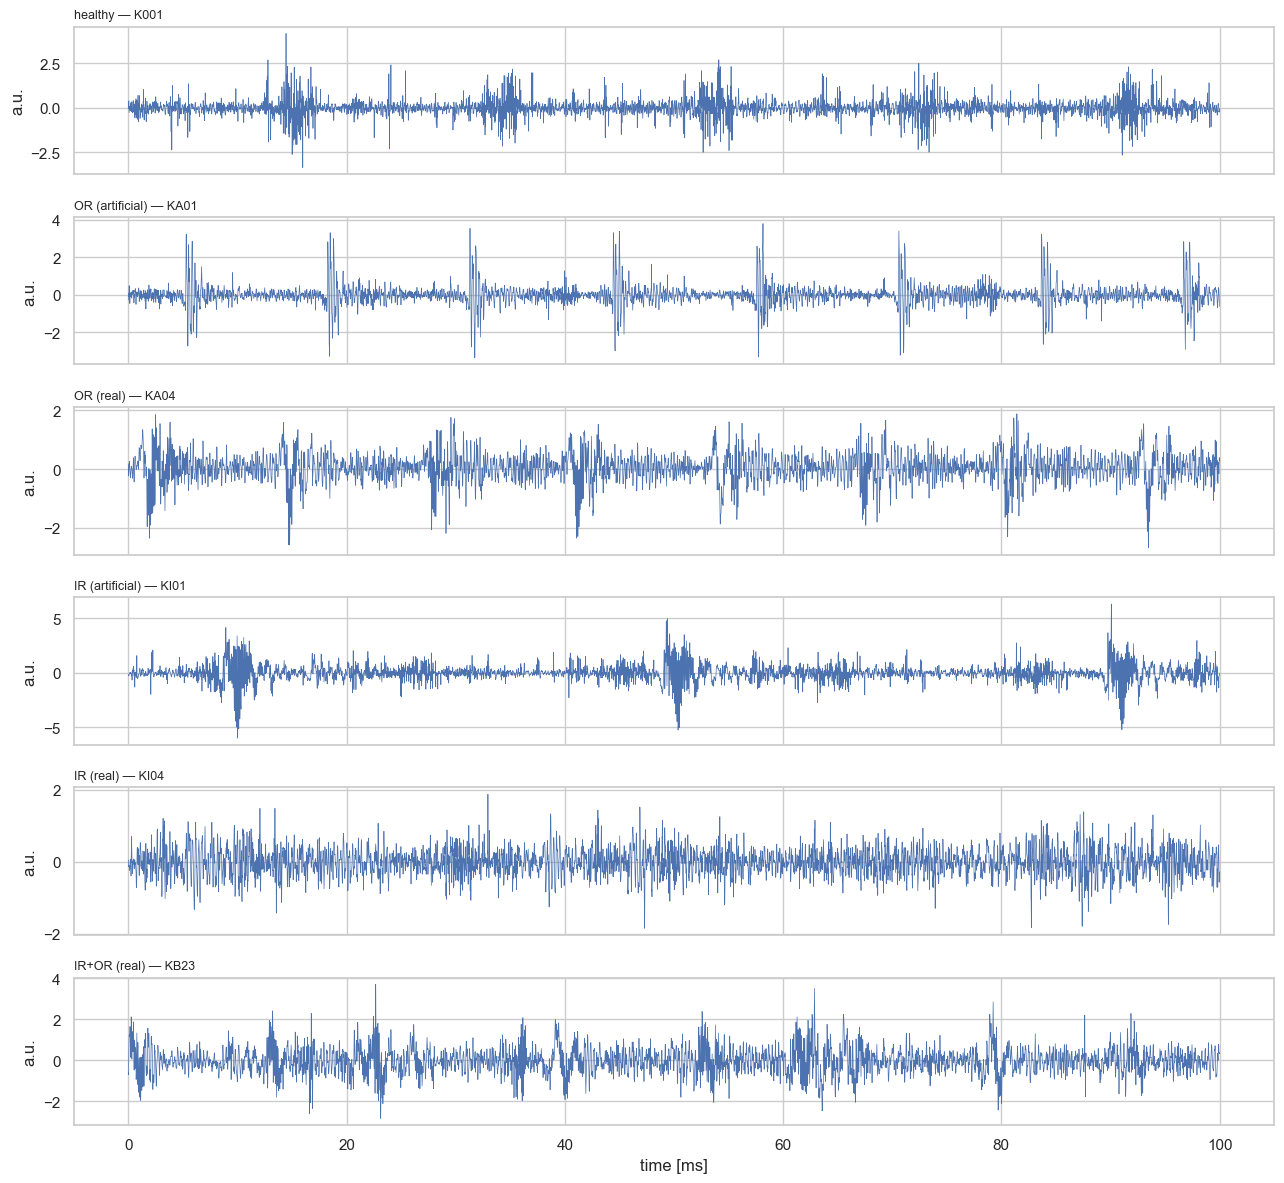

In [82]:
# Time-domain waveforms per class (100 ms snippet)

picks = {"healthy":"K001", "OR (artificial)":"KA01", "OR (real)":"KA04",
         "IR (artificial)":"KI01", "IR (real)":"KI04", "IR+OR (real)":"KB23"}
fig, ax = plt.subplots(len(picks), 1, figsize=(13, 2.0*len(picks)), sharex=True)
for a, (title, b) in zip(ax, picks.items()):
    r = files.query("bearing==@b and cond=='N15_M07_F10' and trial==1").iloc[0]
    x = read_pdb_mat(r.path)["vibration_1"][:int(0.1*FS_FAST)]      # 100 ms
    a.plot(np.arange(x.size)/FS_FAST*1e3, x, lw=.5)
    a.set_title(f"{title} — {b}", loc="left", fontsize=9); a.set_ylabel("a.u.")
ax[-1].set_xlabel("time [ms]"); fig.tight_layout(); fig.savefig(OUT/"waveforms.png", dpi=120)

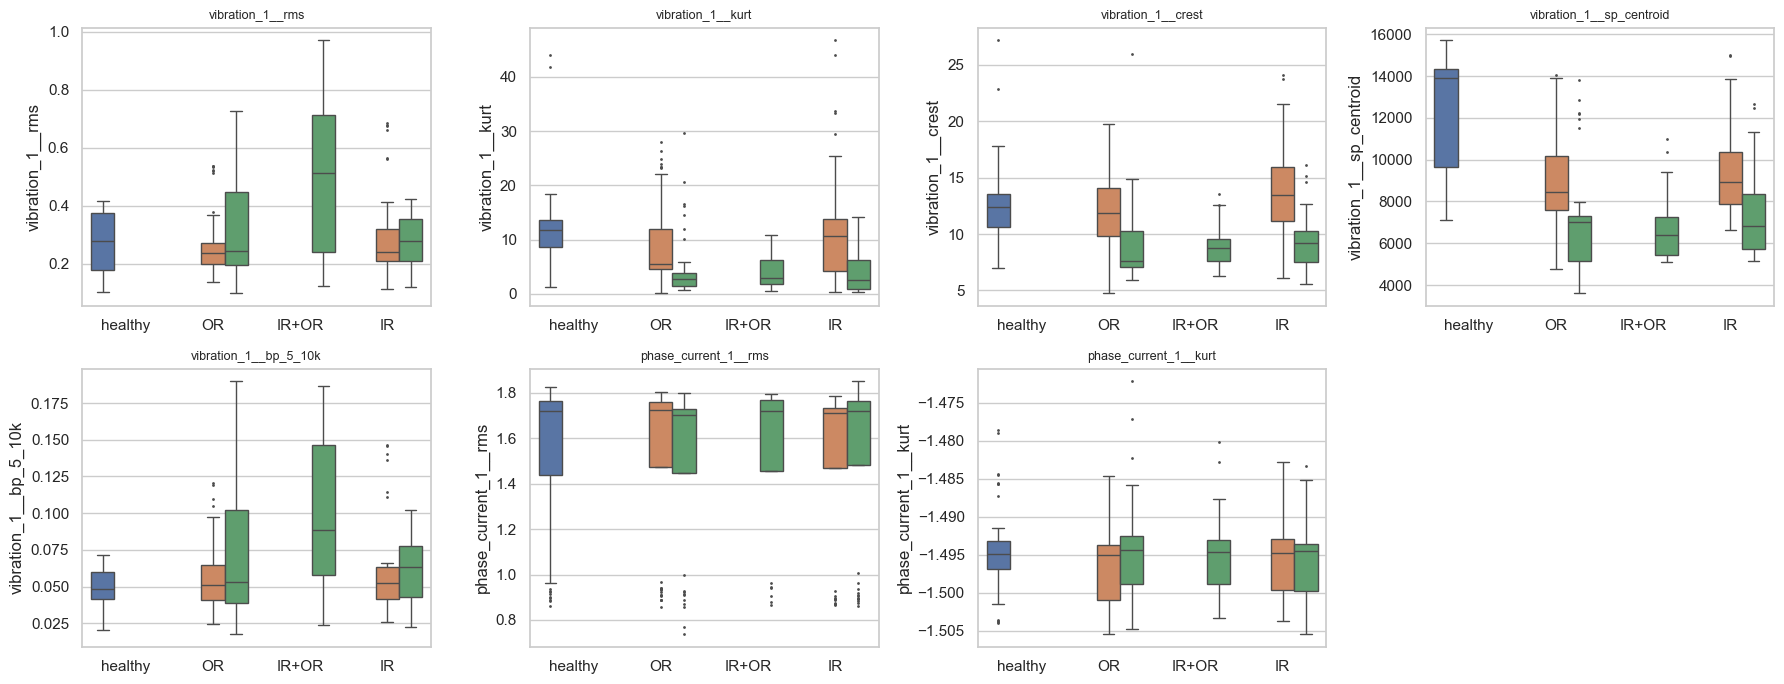

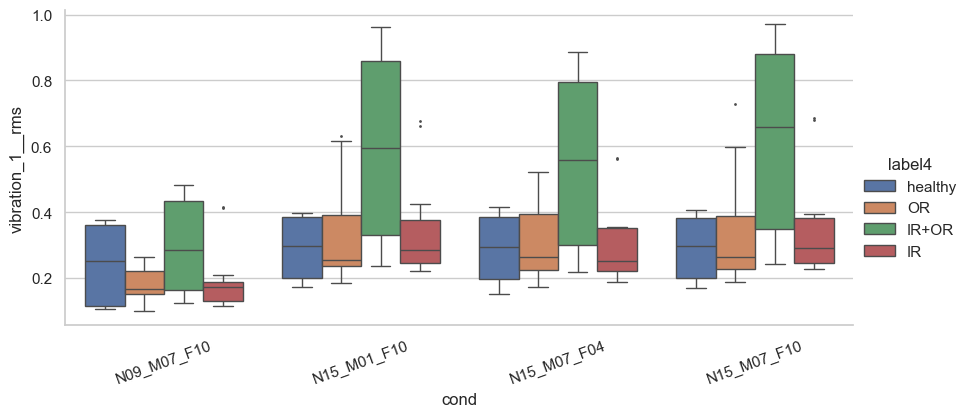

In [83]:
# Feature distributions by class & operating point

fcols = ["vibration_1__rms","vibration_1__kurt","vibration_1__crest","vibration_1__sp_centroid",
         "vibration_1__bp_5_10k","phase_current_1__rms","phase_current_1__kurt"]
fig, ax = plt.subplots(2, 4, figsize=(18, 7))
for a, c in zip(ax.ravel(), fcols):
    sns.boxplot(feat, x="label4", y=c, hue="origin", ax=a, fliersize=1)
    a.set_title(c, fontsize=9); a.set_xlabel(""); a.legend_.remove() if a.legend_ else None
ax.ravel()[-1].axis("off"); fig.tight_layout()

g = sns.catplot(feat, x="cond", y="vibration_1__rms", hue="label4", kind="box",
                height=4, aspect=2.2, fliersize=1)
g.set_xticklabels(rotation=20)

speed__mean                         torque__mean                   force__mean                         temp_2_bearing_module__mean                    
                   mean   std      min      max         mean   std   min   max        mean    std     min      max                        mean   std    min    max
cond                                                                                                                                                              
N09_M07_F10      899.73  0.18   899.36   900.64         1.22  0.03  1.15  1.30     1034.03  41.77  914.37  1115.49                       46.84  4.57  28.66  54.83
N15_M01_F10     1499.65  0.15  1499.22  1500.16         0.62  0.03  0.50  0.71     1047.16  40.68  942.54  1109.87                       45.95  4.50  27.14  52.45
N15_M07_F04     1499.58  0.19  1498.80  1499.98         1.25  0.03  1.21  1.32      419.13  41.08  345.44   530.73                       46.85  4.88  25.85  54.40
N15_M07_F10     1499.60  0.24  1499.10  1500.95         1.26  0.02  1.22  1.33     1032.90  35.18  937.86  1113.19                       48.03  5.07  29.59  58.50

,rpm_set,rpm_meas,trq_set,trq_meas,F_set,F_meas
cond,,,,,,
N09_M07_F10,900,899.73,0.7,1.22,1000,1034.03
N15_M01_F10,1500,1499.65,0.1,0.62,1000,1047.16
N15_M07_F04,1500,1499.58,0.7,1.25,400,419.13
N15_M07_F10,1500,1499.60,0.7,1.26,1000,1032.90


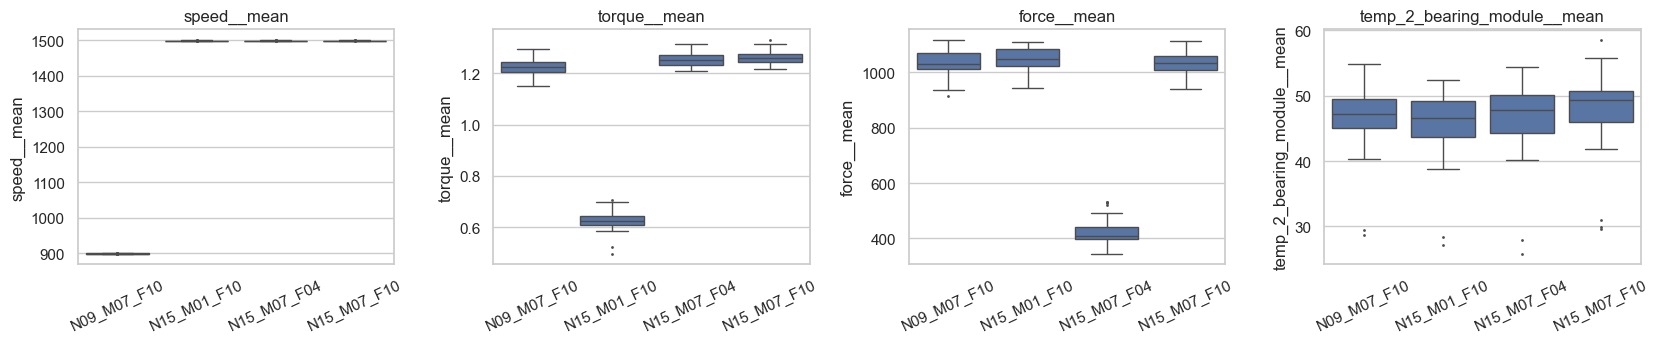

In [84]:
display(feat.groupby("cond")[MEAS_COLS].agg(["mean", "std", "min", "max"]).round(2))

# informational: nominal setpoint vs. measured
display(feat.groupby("cond").agg(rpm_set=("rpm", "first"), rpm_meas=("speed__mean", "mean"),
                                 trq_set=("torque", "first"), trq_meas=("torque__mean", "mean"),
                                 F_set=("radial_force", "first"), F_meas=("force__mean", "mean")
                                 ).round(2))

fig, ax = plt.subplots(1, len(MEAS_COLS), figsize=(4.2*len(MEAS_COLS), 3.6))
for a, c in zip(np.atleast_1d(ax), MEAS_COLS):
    sns.boxplot(data=feat, x="cond", y=c, ax=a, fliersize=1)
    a.set(title=c, xlabel=""); a.tick_params(axis="x", rotation=25)
fig.tight_layout(); fig.savefig(FIG/"conditions.png", dpi=120)

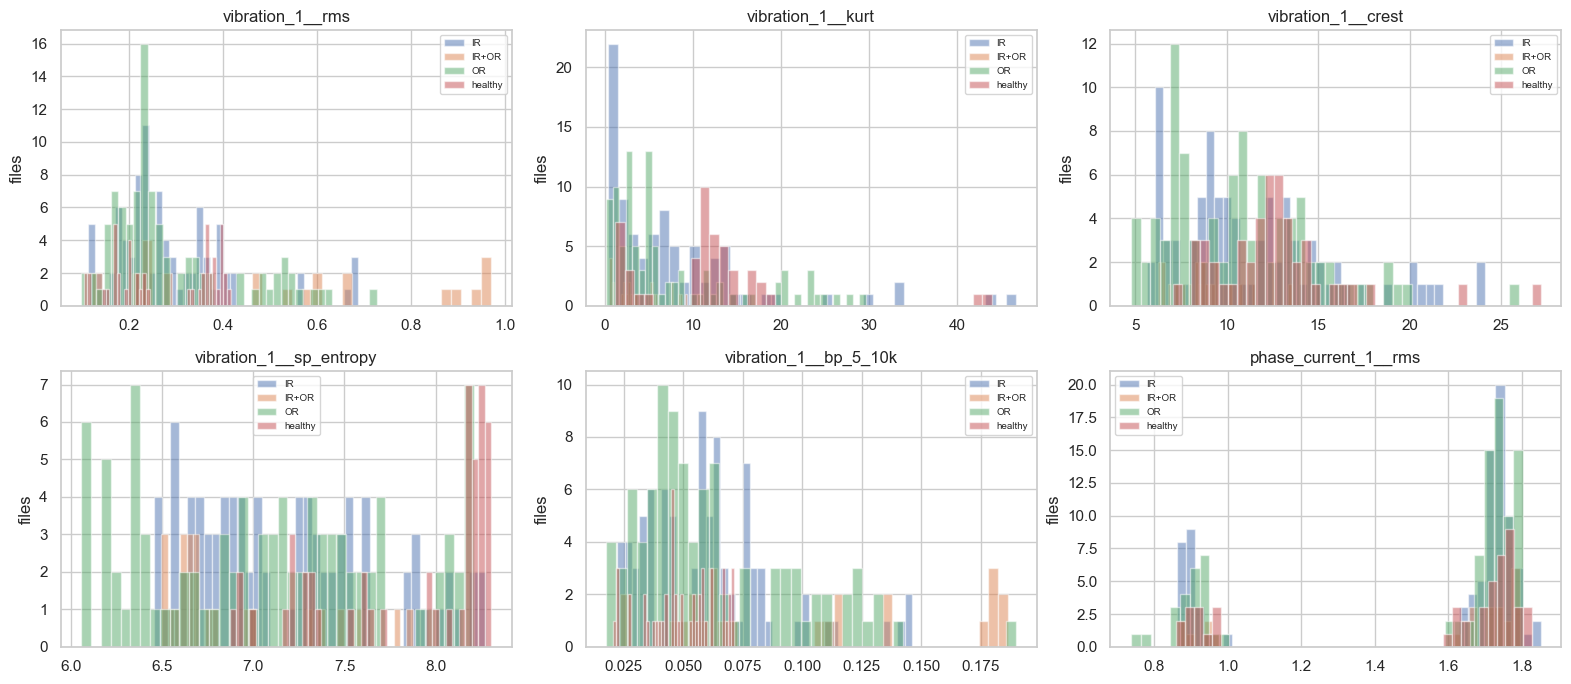

In [85]:
hcols = ["vibration_1__rms", "vibration_1__kurt", "vibration_1__crest",
         "vibration_1__sp_entropy", "vibration_1__bp_5_10k", "phase_current_1__rms"]
hcols = [c for c in hcols if c in feat.columns]

fig, ax = plt.subplots(2, 3, figsize=(16, 7))
for a, c in zip(ax.ravel(), hcols):
    for g, d in feat.groupby(LABEL):
        a.hist(d[c].dropna(), bins=40, alpha=.5, label=g)
    a.set(title=c, ylabel="files"); a.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG/"feature_hists.png", dpi=120)

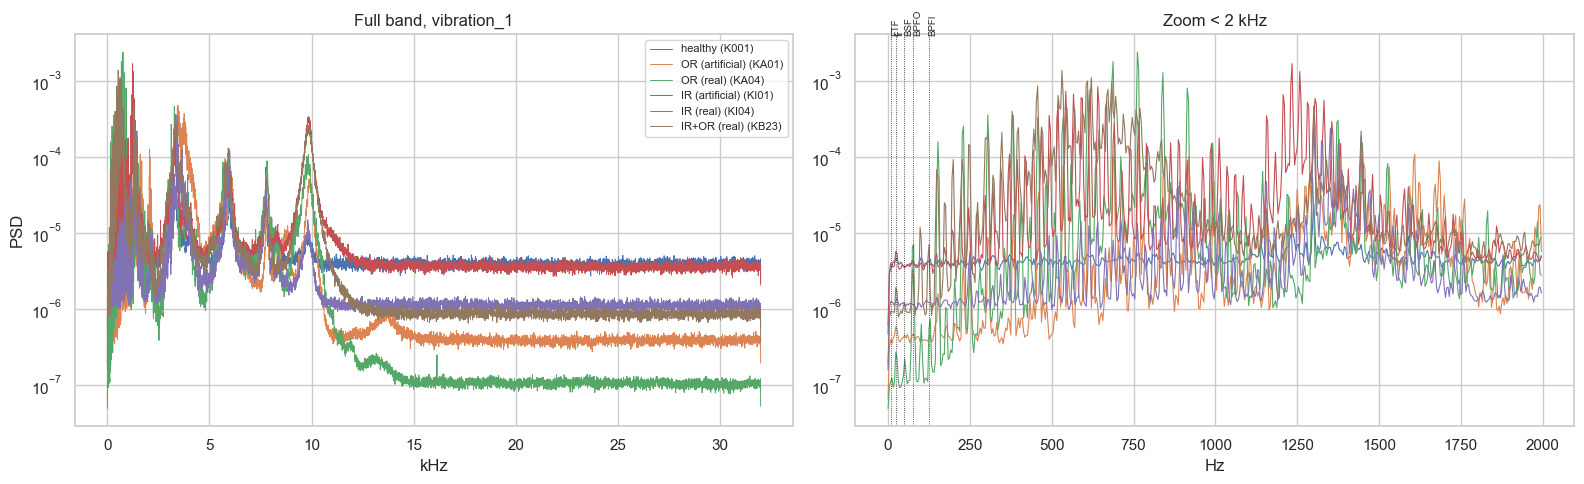

In [86]:
# Class-averaged spectra + bearing fault frequencies

def mean_psd(bearing, cond="N15_M07_F10", ch="vibration_1", k=5, nperseg=16384):
    ps = []
    for _, r in files.query("bearing==@bearing and cond==@cond").head(k).iterrows():
        f, P = signal.welch(read_pdb_mat(r.path)[ch], fs=FS_FAST, nperseg=nperseg)
        ps.append(P)
    return f, np.mean(ps, 0)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for title, b in picks.items():
    f, P = mean_psd(b)
    ax[0].semilogy(f/1000, P, lw=.7, label=f"{title} ({b})")
    ax[1].semilogy(f[f < 2000], P[f < 2000], lw=.8, label=b)
ax[0].set(xlabel="kHz", ylabel="PSD", title="Full band, vibration_1")
ax[1].set(xlabel="Hz", title="Zoom < 2 kHz")
ff = fault_freqs(1500)
for k, v in ff.items():
    ax[1].axvline(v, color="k", ls=":", lw=.6); ax[1].text(v, ax[1].get_ylim()[1], k, fontsize=7, rotation=90)
ax[0].legend(fontsize=8); fig.tight_layout()

Text(0.5, 1.0, 'Spectrogram N15_M07_F10_KI04_1')

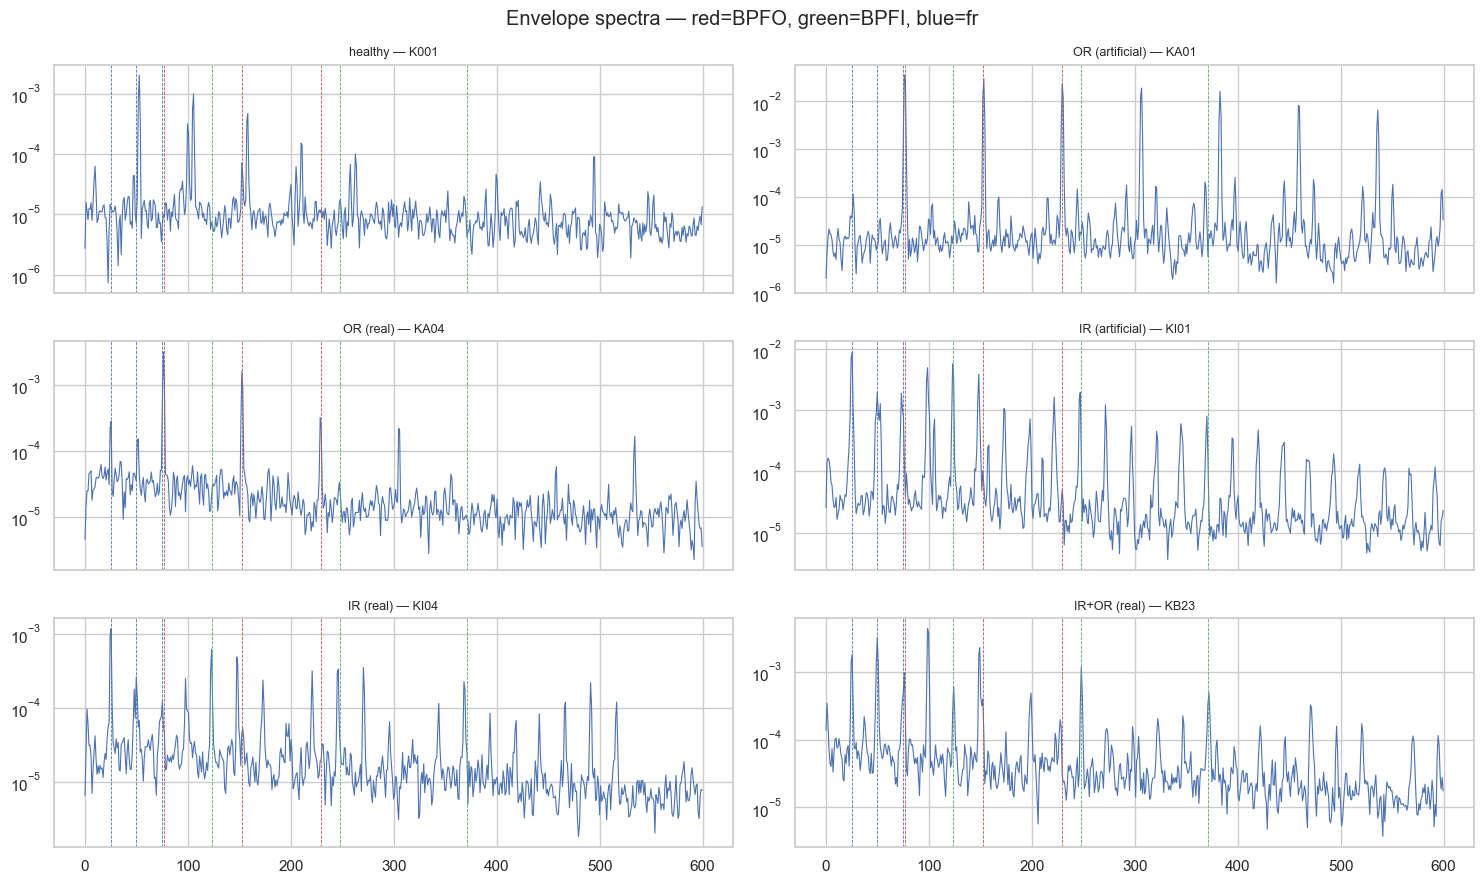

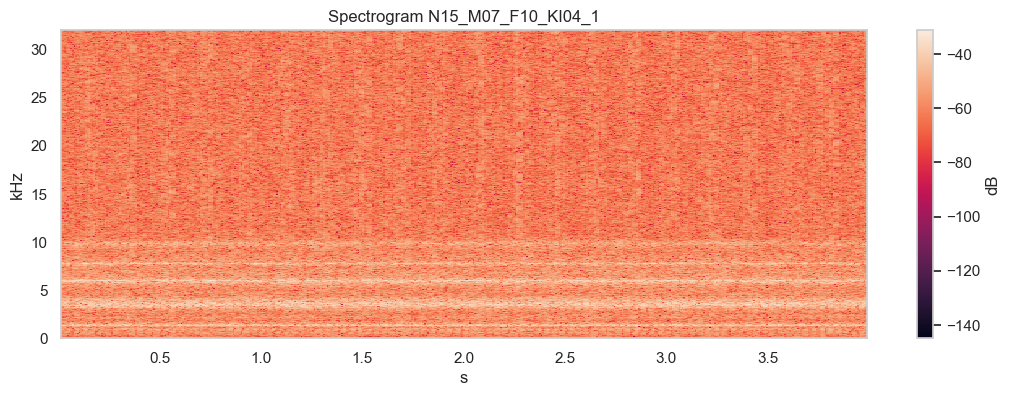

In [87]:
# Envelope spectra (Hilbert transform) + bearing fault frequencies
# Envelope spectrum (the diagnostic view) + spectrogram

def envelope_spectrum(x, fs=FS_FAST, band=(2000, 10000), fmax=600):
    sos = signal.butter(4, band, btype="bandpass", fs=fs, output="sos")
    env = np.abs(signal.hilbert(signal.sosfiltfilt(sos, x)))
    env -= env.mean()
    f, P = signal.welch(env, fs=fs, nperseg=2**16)
    return f[f <= fmax], P[f <= fmax]

fig, ax = plt.subplots(3, 2, figsize=(15, 9), sharex=True)
for a, (title, b) in zip(ax.ravel(), picks.items()):
    r = files.query("bearing==@b and cond=='N15_M07_F10'").iloc[0]
    f, P = envelope_spectrum(read_pdb_mat(r.path)["vibration_1"])
    a.plot(f, P, lw=.8); a.set_yscale("log"); a.set_title(f"{title} — {b}", fontsize=9)
    for k, c in zip(("BPFO","BPFI","fr"), ("r","g","b")):
        for h in range(1, 4):
            a.axvline(ff[k]*h, color=c, ls="--", lw=.6)
fig.suptitle("Envelope spectra — red=BPFO, green=BPFI, blue=fr"); fig.tight_layout()

r = files.query("bearing=='KI04' and cond=='N15_M07_F10'").iloc[0]
x = read_pdb_mat(r.path)["vibration_1"]
f, t, S = signal.spectrogram(x, fs=FS_FAST, nperseg=2048, noverlap=1536)
plt.figure(figsize=(13,4)); plt.pcolormesh(t, f/1000, 10*np.log10(S+1e-20), shading="auto")
plt.ylabel("kHz"); plt.xlabel("s"); plt.colorbar(label="dB"); plt.title(f"Spectrogram {r.file_id}")

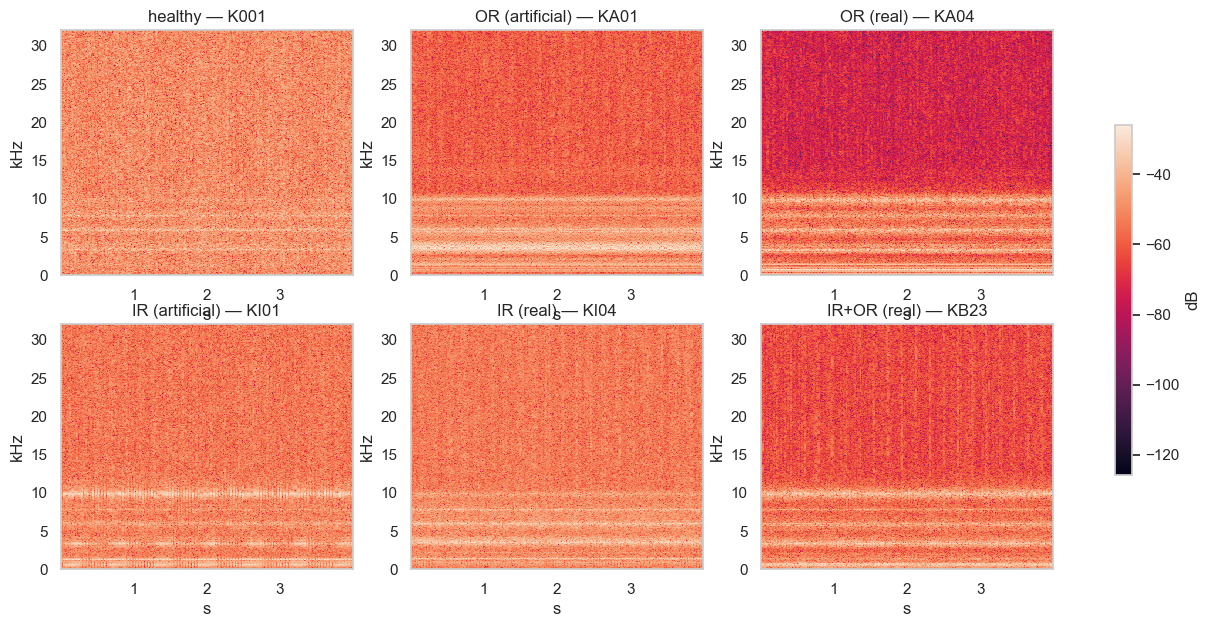

In [88]:
fig, ax = plt.subplots(2, 3, figsize=(16, 7)); im = None
for a, r in zip(ax.ravel(), picks_df.itertuples()):
    ch = try_read(r.path)
    if ch is None or "vibration_1" not in ch:
        a.axis("off"); continue
    f, t, S = signal.spectrogram(ch["vibration_1"][:N_KEEP], fs=FS_FAST,
                                 nperseg=2048, noverlap=1536)
    im = a.pcolormesh(t, f/1000, 10*np.log10(S + 1e-20), shading="auto")
    a.set(title=f"{r.title} — {r.bearing}", xlabel="s", ylabel="kHz")
if im is not None:
    fig.colorbar(im, ax=ax.ravel().tolist(), shrink=.65, label="dB")
fig.savefig(FIG/"spectrograms.png", dpi=120)

In [89]:
for a, r in zip(ax.ravel(), picks_df.itertuples()):
    ch = try_read(r.path)
    if ch is None: a.axis("off"); continue
    f, P = envelope_spectrum(ch["vibration_1"][:N_KEEP])
    ffr = fault_freqs(r.rpm)                    # ← per-row, not hard-coded 1500
    a.plot(f, P, lw=.8); a.set_yscale("log")
    a.set_title(f"{r.title} — {r.bearing} @ {r.rpm} rpm", fontsize=9)
    for k, c in zip(("BPFO", "BPFI", "fr"), ("r", "g", "b")):
        for h in (1, 2, 3):
            a.axvline(ffr[k]*h, color=c, ls="--", lw=.6)

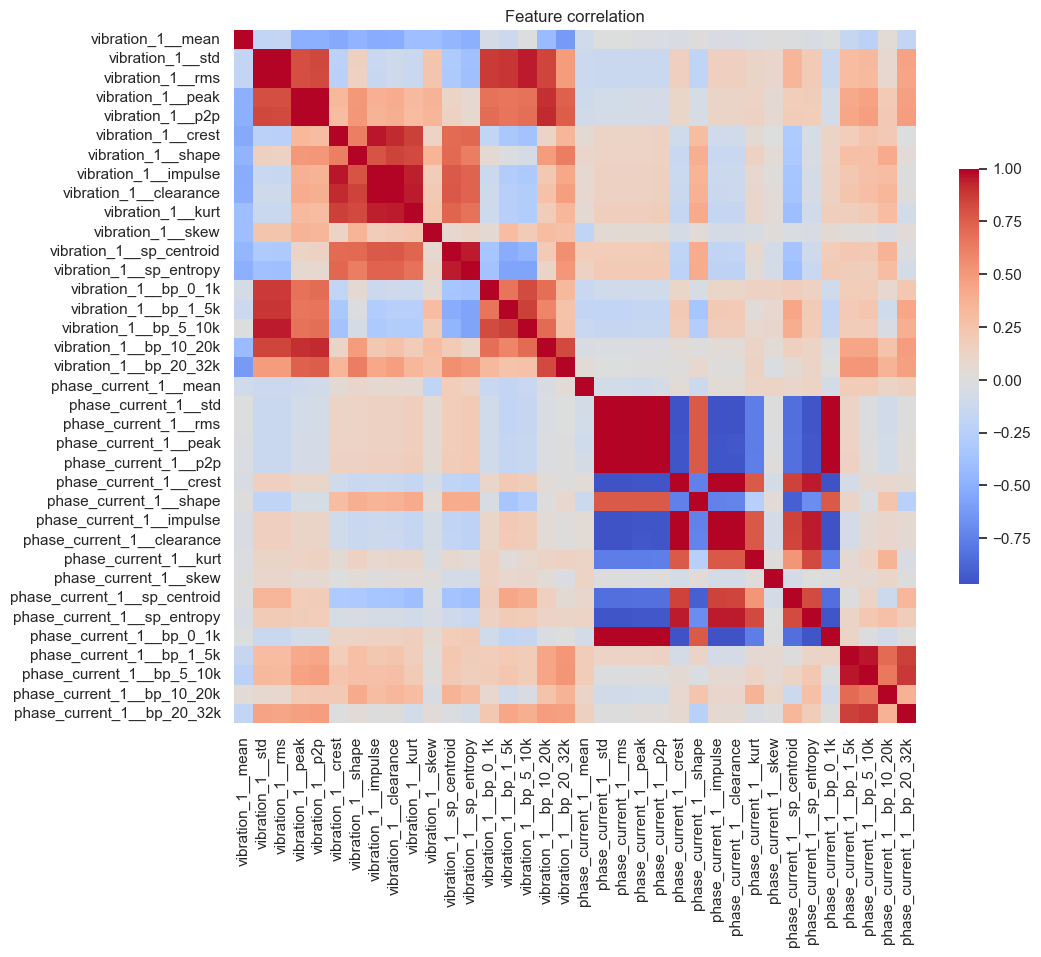

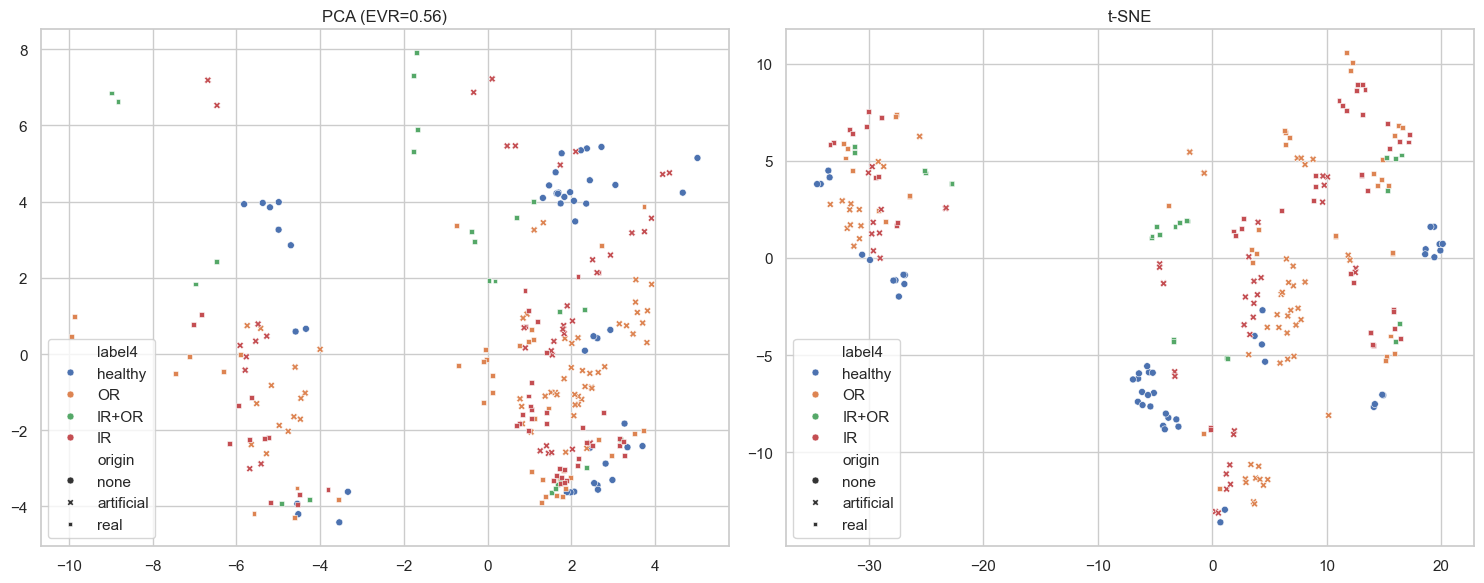

In [90]:
# Dimensionality reduction (PCA + t-SNE) on vibration_1 & phase_current_1 features
# Correlation, PCA, t‑SNE (separability check)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

F = feat.filter(regex="^(vibration_1|phase_current_1)__").dropna(axis=1, how="any")
plt.figure(figsize=(11,9)); sns.heatmap(F.corr(), cmap="coolwarm", center=0,
                                        xticklabels=True, yticklabels=True,
                                        cbar_kws={"shrink":.6}); plt.title("Feature correlation")

Z = StandardScaler().fit_transform(F.values)
p = PCA(2).fit(Z); emb = p.transform(Z)
t = TSNE(2, perplexity=30, init="pca", random_state=SEED).fit_transform(Z)
fig, ax = plt.subplots(1, 2, figsize=(15,6))
for a, e, name in zip(ax, (emb, t), (f"PCA (EVR={p.explained_variance_ratio_.sum():.2f})", "t-SNE")):
    sns.scatterplot(x=e[:,0], y=e[:,1], hue=feat.label4, style=feat.origin, s=25, ax=a)
    a.set_title(name)
fig.tight_layout()

|r| > 0.95 — candidates for removal:


,,r
phase_current_1__std,phase_current_1__bp_0_1k,0.999999
phase_current_2__std,phase_current_2__bp_0_1k,0.999999
phase_current_1__std,phase_current_1__rms,0.999999
phase_current_1__rms,phase_current_1__bp_0_1k,0.999998
phase_current_2__std,phase_current_2__rms,0.999967
phase_current_2__rms,phase_current_2__bp_0_1k,0.999966
phase_current_1__bp_0_1k,phase_current_2__bp_0_1k,0.999936
phase_current_1__std,phase_current_2__bp_0_1k,0.999935
phase_current_1__rms,phase_current_2__bp_0_1k,0.999935
vibration_1__std,vibration_1__rms,0.999934


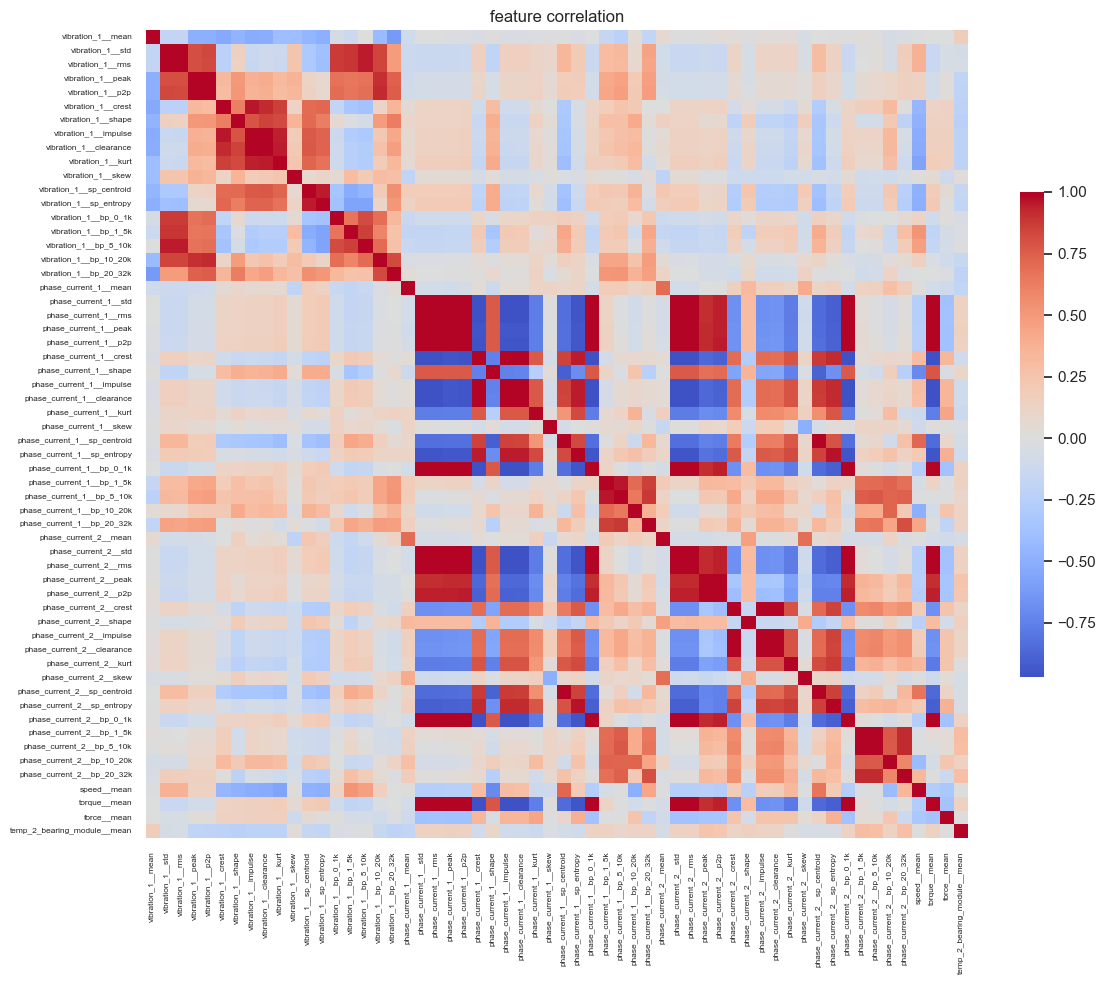

In [91]:
Fnum = feat[FEAT_COLS].dropna(axis=1, how="any")
C = Fnum.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(C, cmap="coolwarm", center=0, xticklabels=True, yticklabels=True,
            cbar_kws={"shrink": .6}, ax=ax)
ax.set_title("feature correlation"); ax.tick_params(labelsize=6)
fig.tight_layout(); fig.savefig(FIG/"corr.png", dpi=120)

u = C.where(np.triu(np.ones(C.shape), 1).astype(bool)).stack()
print("|r| > 0.95 — candidates for removal:")
display(u[u.abs() > .95].sort_values(key=abs, ascending=False).to_frame("r").head(20))

In [92]:
# Leakage rule: never put windows/files of the SAME bearing in train and test.
#  Split strategy check (do this before modelling)

ARTIFICIAL = [b for b,(c,o,*_) in DAMAGE_CATALOG.items() if o == "artificial"]
REAL       = [b for b,(c,o,*_) in DAMAGE_CATALOG.items() if o == "real"]
HEALTHY    = [b for b,(c,o,*_) in DAMAGE_CATALOG.items() if c == "healthy"]

splits = {
 # (a) hardest & most cited: learn on artificial damage, test on real damage
 "artificial_to_real": {"train": ARTIFICIAL + HEALTHY[:4], "test": REAL + HEALTHY[4:]},
 # (b) group-holdout on real damage only
 "real_bearing_holdout": {"train": [b for b in REAL if b not in ("KA16","KI16","KB24")] + HEALTHY[:4],
                          "test":  ["KA16","KI16","KB24"] + HEALTHY[4:]},
 # (c) cross-domain over operating points (bearing-disjoint not required, cond-disjoint is)
 "cross_condition": {"train_cond": ["N15_M07_F10"], "test_cond": ["N09_M07_F10","N15_M01_F10","N15_M07_F04"]},
}
json.dump(splits, open(OUT/"splits.json","w"), indent=2)
for k, v in splits.items():
    print(k, {kk: len(vv) for kk, vv in v.items()})

artificial_to_real {'train': 16, 'test': 16}
real_bearing_holdout {'train': 15, 'test': 5}
cross_condition {'train_cond': 1, 'test_cond': 3}


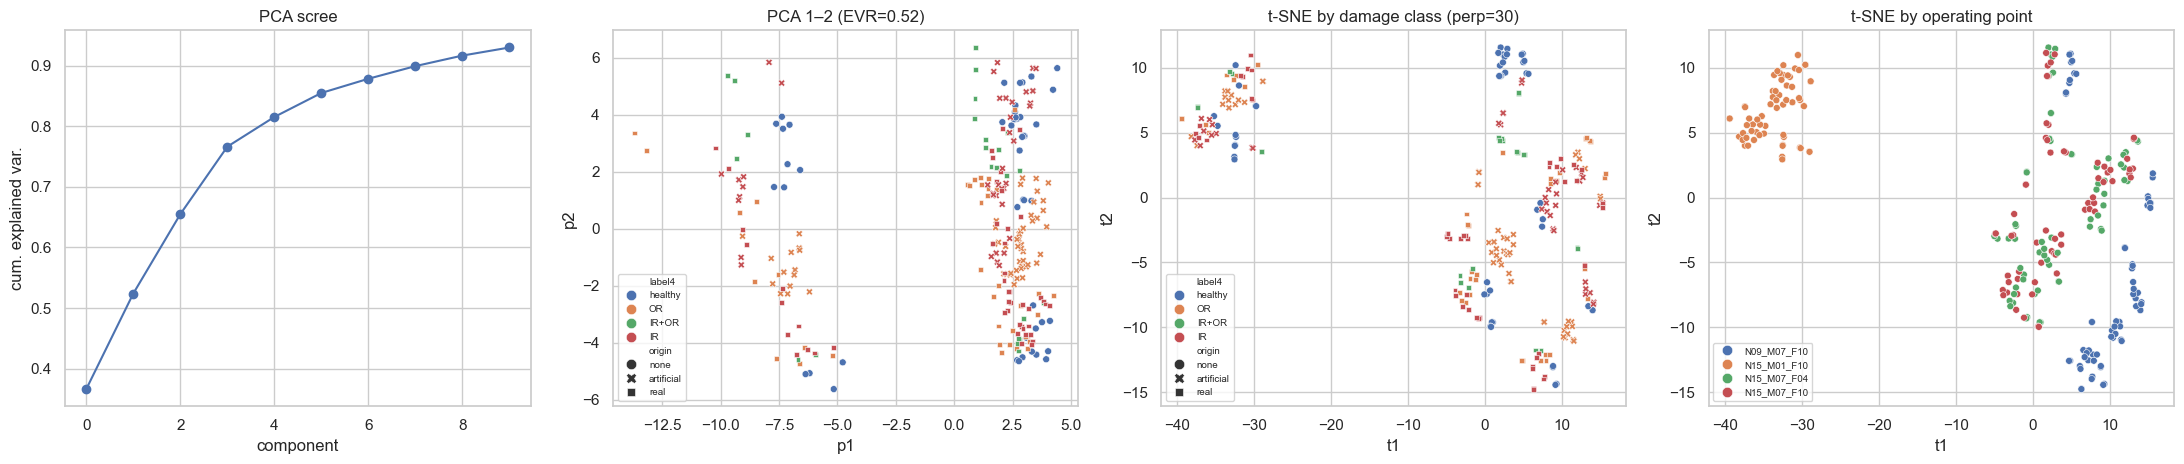

In [93]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X = StandardScaler().fit_transform(Fnum.values)          # setpoints excluded by construction
pca = PCA(n_components=min(10, X.shape[1])).fit(X); Z = pca.transform(X)
perp = min(30, max(5, (len(X) - 1) // 3))
ts = TSNE(2, perplexity=perp, init="pca", random_state=SEED).fit_transform(Z)

E = feat.loc[Fnum.index].assign(p1=Z[:, 0], p2=Z[:, 1], t1=ts[:, 0], t2=ts[:, 1])

fig, ax = plt.subplots(1, 4, figsize=(22, 4.8))
ax[0].plot(np.cumsum(pca.explained_variance_ratio_), "o-")
ax[0].set(xlabel="component", ylabel="cum. explained var.", title="PCA scree")
sns.scatterplot(data=E, x="p1", y="p2", hue=LABEL, style="origin", s=25, ax=ax[1])
ax[1].set(title=f"PCA 1–2 (EVR={pca.explained_variance_ratio_[:2].sum():.2f})")
sns.scatterplot(data=E, x="t1", y="t2", hue=LABEL, style="origin", s=25, ax=ax[2])
ax[2].set(title=f"t-SNE by damage class (perp={perp})")
sns.scatterplot(data=E, x="t1", y="t2", hue="cond", s=25, ax=ax[3])
ax[3].set(title="t-SNE by operating point")     # if this separates better → domain shift
for a in ax[1:]: a.legend(fontsize=7, markerscale=1.5)
fig.tight_layout(); fig.savefig(FIG/"pca_tsne.png", dpi=120)